In [1]:
import dataParsing

text_parser = dataParsing.text_parser

Read the data using the dataParsing modules, to get a dictionary with the word:Counter pairs. The data is not on the repository due to copyright reasons. 

Data source: https://www1.dict.cc/translation_file_request.php?l=e

In [8]:
text_parser.empty_dictionary()


with open("data.txt", "r", encoding="utf-8") as r:
    for line in r:
        text_parser.parse(line)

dict = text_parser.dictionary

In [9]:
data = {k : v.most_common(1)[0][0] for k, v in dict.items()}

In [10]:
import pandas as pd

dataset = pd.DataFrame.from_dict(data, orient='index')

dataset.reset_index(inplace=True)

dataset = dataset.rename(columns = {'index': "word", 0: "gender"})

dataset.tail(10)

,word,gender
382370,Löschungsort,m
382371,Cejkait,m
382372,Hydroxybutansäure,f
382373,Hydroxybuttersäure,f
382374,Methylstyrol,n
382375,Tomatin,n
382376,Cryptoxanthin,n
382377,Cyclocitral,n
382378,Propellerdomäne,f
382379,Glutamyltransferase,f


0: 382380
1: 382380
2: 382274
3: 381543
4: 379082
5: 374232
6: 366589
7: 355502
8: 337259
9: 310761
10: 276809
11: 239660
12: 203201
13: 168012
14: 136497
15: 107506
16: 82696
17: 61997
18: 45370
19: 32425
20: 22631
21: 15588
22: 10535
23: 7111
24: 4815
25: 3215
26: 2173
27: 1450
28: 975
29: 628
30: 433
31: 286
32: 194
33: 128
34: 90
35: 65
36: 43
37: 35
38: 25
39: 19
40: 10
41: 7
42: 4
43: 3
44: 3
45: 3
46: 2
47: 2
48: 2
49: 2
50: 2
51: 2
52: 2
53: 2
54: 2
55: 2
56: 2
57: 2
58: 2
59: 2
60: 2
61: 2
62: 2
63: 1
64: 1
65: 1
66: 1
67: 0
Total number of words: 382380
Percentage of feminine nouns: 44.16%
Percentage of masculine nouns: 34.25%
Percentage of neutral nouns: 21.59%
Longest word: Grundstücksverkehrsgenehmigungszuständigkeitsübertragungsverordnung (67 letters)
Input size: 67x30 = 2010


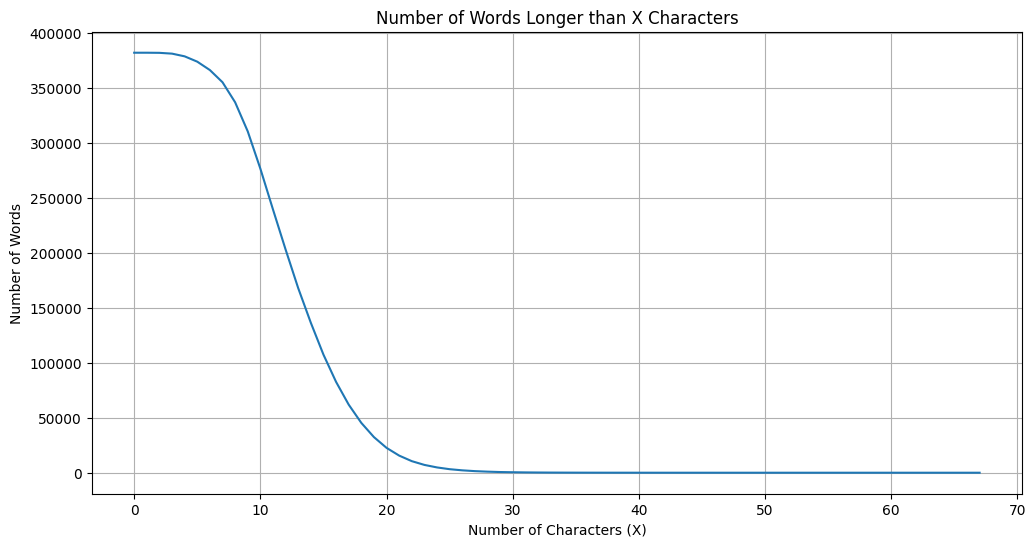

In [14]:
import pandas as pd
import matplotlib.pyplot as plt

# Assuming 'dataset' is already loaded
data_f = dataset[dataset['gender'] == "f"]
data_m = dataset[dataset['gender'] == "m"]
data_n = dataset[dataset['gender'] == "n"]
longest_word = max(dataset['word'], key=len)
possible_characters = "abcdefghijklmnopqrstuvwxyzäöüß"

# Calculate word length distribution
max_length = len(longest_word)
word_lengths = [len(word) for word in dataset['word']]
length_counts = [sum(length > x for length in word_lengths) for x in range(max_length + 1)]

for i in range(len(length_counts)):
    print(f"{i}: {length_counts[i]}")

# Create the plot
plt.figure(figsize=(12, 6))
plt.plot(range(max_length + 1), length_counts)
plt.title("Number of Words Longer than X Characters")
plt.xlabel("Number of Characters (X)")
plt.ylabel("Number of Words")
plt.grid(True)

# Print statistics
print("Total number of words:", len(dataset))
print(f"Percentage of feminine nouns: {len(data_f)/len(dataset)*100:.2f}%")
print(f"Percentage of masculine nouns: {len(data_m)/len(dataset)*100:.2f}%")
print(f"Percentage of neutral nouns: {len(data_n)/len(dataset)*100:.2f}%")
print(f"Longest word: {longest_word} ({len(longest_word)} letters)")
print(f"Input size: {max_length}x{len(possible_characters)} = {max_length*len(possible_characters)}")

# Show the plot
plt.show()

In [ ]:
#save dataset as csv

def save_dataset():
    dataset.to_csv("dataset.csv", index=False)

save_dataset()
    